<a href="https://colab.research.google.com/github/Lillie-Walden/Lab-4/blob/main/Assignments/assignment_04_data_understanding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IS4487 Week 4 - Assignment

### Outline

Our Goals with this Project:

1. Import and review the data
2. Perform EDA and Clean Data

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_04_data_understanding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Business Case: AdviseInvest
You work on a small team of data analysts at AdviseInvest, a venture-backed startup. The Director of Sales at AdviseInvest has approached your team asking for help solving a staffing problem.

### The Company
The company's mission is to provide tools and support to help ordinary people gain control of their personal finances. The company leverages technology to provide affordable financial advice to a national client base.

Customers who reach AdviseInvest's website go through five steps:

- Open an account.
- Complete a customer profile form with basic information about their background and finances.
- Schedule a free phone conversation with a sales representative during a 1-hour window of time.
- Attend the free phone conversation.
- Buy a financial plan.
- There are three types of financial plans: Beginner, Intermediate, and Advanced. Each is sold at a different price, and there are varying degrees of personalization. After a customer purchases a financial plan, the customer is assigned a financial planner who helps determine the customer's goals and advises the customer on spending decisions.

### The Problem
Some customers are lost at each stage of the process. Steps 3 and 4 are particularly challenging because approximately 50% of those who schedule a phone conversation fail to pick up the call. This leads to inefficiencies from a staffing perspective.

AdviseInvest has 4 sales reps on staff during each particular 1-hour window. Each of the 4 reps is assigned 2 prospective customers per hour, which means that the company schedules a total of 8 phone calls per hour. The calls are outgoing: sales reps call customers who scheduled a phone conversation during that hour window.

Unfortunately, as noted above, many of the customers who scheduled a call do not answer. As a consequence, sales reps are often left underutilized. Moreover, they are underutilized unevenly. For example, it is possible that one sales rep will not do any sales calls during that hour, whereas another will be busy the entire hour with two calls. Sales reps have nothing to do when customers do not answer the scheduled phone call.

For this assignment, the variable `answered` is your target.  

### AdviseInvest Data Dictionary

| Variable | Description | Type | Code |
|:---|:---|:---|:---|
| customer_id | Unique customer identifier | Numeric | |
| Answered | Customer response | Binary | 0: customer did not answer scheduled call; 1: customer answered scheduled call |
| Income | Customer income in US dollars | Numeric | |
| Female | Customer gender | Binary | 0: female; 1: male |
| Age | Age in years | Numeric | |
| Job | Nature of job | Categorical | 0 : unemployed; 1 : entry level position; 2 : midlevel position; 3 : management/ self-employed/ highly qualified employee/ officer |
| Num_dependents | Number of people for whom the customer provides maintenance | Numeric | |
| Rent | Customer rents | Binary | 0: no; 1: yes |
| Own_res | Customer owns residence | Binary | 0: no; 1: yes |
| New_car | Recent new car purchase | Binary | New car purchase in the last 3 months: 0: no, 1: yes |
| Chk_acct | Checking account status | Categorical | 0 : no checking account; 1: checking < 200 USD; 2 : 200 < checking < 2000 USD; 3: 2000 < checking < 35000 USD; 4: >= 3500 USD |
| Sav_acct | Average balance in savings account | Categorical | 0 : no savings account; 1 : 100 <= savings < 500 USD; 2 : 500 <= savings < 2000 USD; 3 : 2000 < savings < 35000 USD; 4: >= 3500 USD |
| Num_accts | Number of accounts owned by customer | Numeric | |
| Mobile | Mobile phone | Binary | 0: customer provided non‐mobile phone for follow‐up call; 1: customer provided mobile phone for follow‐up call |
| Product | Type of product purchased after conversation with sales rep | Categorical | 0: customer did not answer call; 1: customer answered but did not purchase a product; 2: customer answered and purchased Beginner plan; 3: customer answered and purchased Intermediate plan; 4: customer answered and purchased Advanced plan |


### Load Libraries

Import the libraries you will need, such as:
- Pandas
- Sklearn
- Matplotlib


In [1]:
#Import libraries 🔧
import pandas as pd
import sklearn
import matplotlib.pyplot as plt

## Step 1: Initial Data Understanding

### Do the following:
 1. Import data from the AdviseInvest historical dataset into a dataframe (in GitHub go to the DataSets folder and look for `adviseinvest_historical_data.csv`)
 2. Show the datatypes
 3. Describe the dataset

 Think about if there are any outliers, missing values, or duplicates.  We will cover those topics more next week.  

In [2]:
#Import the data 🔧
df = pd.read_csv('https://raw.githubusercontent.com/Stan-Pugsley/is_4487_base/main/DataSets/adviseinvest_historical_data.csv')
display(df.head())

,customer_id,answered,income,female,age,job,num_dependents,rent,own_res,new_car,chk_acct,sav_acct,num_accts,mobile,product
0,10098,0,-65600,0,24,2,1,0,1,1.0,1,1,3,0,0
1,184,0,4330,0,24,2,2,1,0,0.0,1,3,1,0,0
2,194,0,4330,0,22,2,1,1,0,0.0,3,0,0,0,0
3,689,0,4330,0,24,2,2,1,0,0.0,1,3,1,0,0
4,811,0,4330,0,22,2,1,1,0,0.0,3,0,0,0,0


In [3]:
#View the datatypes 🔧
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29504 entries, 0 to 29503
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   customer_id     29504 non-null  int64  
 1   answered        29504 non-null  int64  
 2   income          29504 non-null  int64  
 3   female          29504 non-null  object 
 4   age             29504 non-null  int64  
 5   job             29504 non-null  int64  
 6   num_dependents  29504 non-null  int64  
 7   rent            29504 non-null  int64  
 8   own_res         29504 non-null  int64  
 9   new_car         29502 non-null  float64
 10  chk_acct        29504 non-null  int64  
 11  sav_acct        29504 non-null  int64  
 12  num_accts       29504 non-null  int64  
 13  mobile          29504 non-null  int64  
 14  product         29504 non-null  int64  
dtypes: float64(1), int64(13), object(1)
memory usage: 3.4+ MB


In [4]:
#Describe the data 🔧
display(df.describe())

,customer_id,answered,income,age,job,num_dependents,rent,own_res,new_car,chk_acct,sav_acct,num_accts,mobile,product
count,29504.000000,29504.000000,29504.000000,29504.000000,29504.000000,29504.000000,29504.000000,29504.000000,29502.000000,29504.000000,29504.000000,29504.000000,29504.000000,29504.000000
mean,14850.475563,0.546638,33766.893303,34.773454,1.915401,1.140998,0.210412,0.681128,0.240797,1.468547,0.956616,2.458345,0.091106,1.535792
std,8517.254310,0.497829,29379.202710,11.369865,0.658183,0.348025,0.407608,0.466047,0.427575,1.234727,1.483946,19.497380,0.287765,1.625916
min,99.000000,0.000000,-65600.000000,19.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7474.750000,0.000000,13550.000000,26.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000
50%,14850.500000,1.000000,23310.000000,32.000000,2.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,2.000000,0.000000,1.000000
75%,22226.250000,1.000000,41690.000000,40.000000,2.000000,1.000000,0.000000,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,3.000000
max,29602.000000,1.000000,159450.000000,132.000000,3.000000,2.000000,1.000000,1.000000,1.000000,3.000000,4.000000,3345.000000,1.000000,4.000000


Question 1.4: Do you see any variables that have potential outliers?  What indicators do you see the the values are out of the normal range?  (don't worry about using a scientific approach for outliers at this stage; just use your best judgment)

### ✍️ Your Response: 🔧
1.4. I think it is odd that the minimum income value is -65,600 because income cannot be negative, so I am unsure what happened here. This is a clear outlier, but also a variable that is not possible. The same thing happened with the maximum age variable, which is 132. This is not impossible I guess, but highly unlikely, so I think that it is once again an outlier but also an error with the dataset somewhere. The other high value is the number of accounts, which is 3345. This is a clear outlier because someone would probably not have that many accounts, or maybe once again this is an error in the dataset. That is what we need to distinguish between.

# Step 2: Begin to Explore the Data

We will learn more about Exploratory Data Analysis (EDA) in Week 5. The following steps are to help you connect the data visualization steps that we practiced last week with the process of data understanding - learning more about the dataset and finding the data quality issues that need to be addressed.   These are the first steps in EDA.

### Do the following:
- Explore the relationships between the target and independent variables
- Create at least five charts to show the relationships, using different chart types that are approriate to the analysis
- Ensure that all charts are clearly labeled and formatted

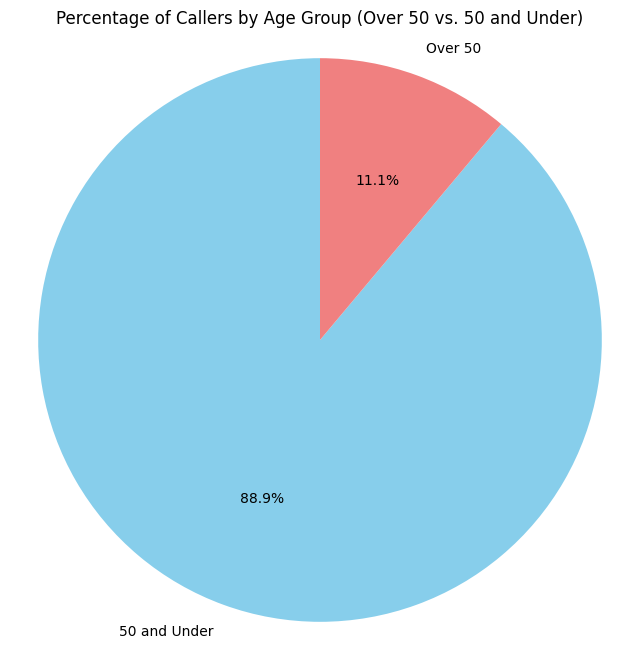

In [6]:
# Chart 1 🔧
import matplotlib.pyplot as plt

# Calculate percentages directly by filtering for answered calls and categorizing age
percentages = df[df['answered'] == 1]['age'].apply(lambda x: 'Over 50' if x > 50 else '50 and Under').value_counts(normalize=True) * 100

# Create the pie chart
fig = plt.figure(figsize=(8, 8))
plt.pie(percentages, labels=percentages.index, autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightcoral'])
plt.title('Percentage of Callers by Age Group (Over 50 vs. 50 and Under)')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

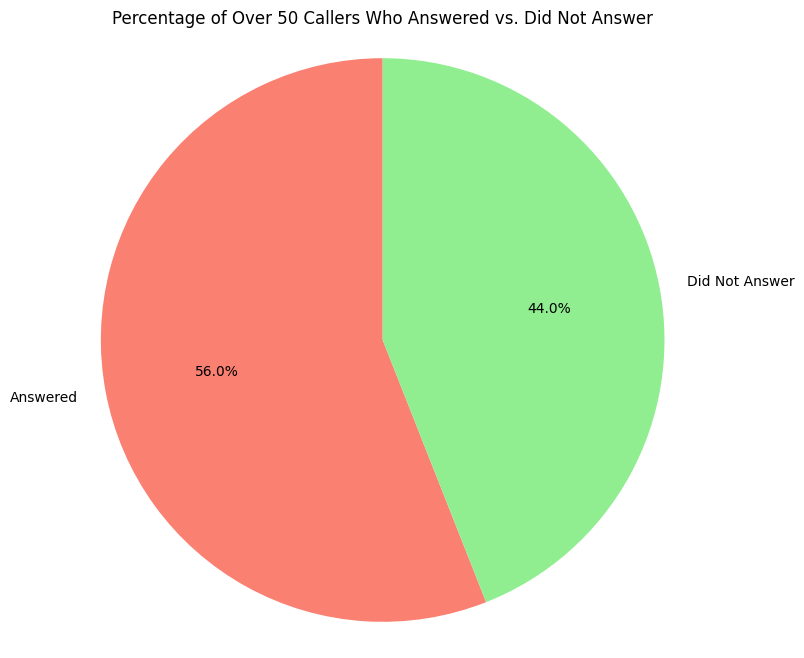

In [7]:
# Chart 2 🔧

import matplotlib.pyplot as plt

# Filter for callers over 50 years old
over_50_callers = df[(df['age'] > 50)]

# Calculate the percentage of 'answered' vs. 'not answered' within this group
answered_percentages_over_50 = over_50_callers['answered'].value_counts(normalize=True) * 100

# Map the 'answered' values to more descriptive labels for the pie chart
labels = answered_percentages_over_50.index.map({0: 'Did Not Answer', 1: 'Answered'})

# Create the pie chart
fig = plt.figure(figsize=(8, 8))
plt.pie(answered_percentages_over_50, labels=labels, autopct='%1.1f%%', startangle=90, colors=['salmon', 'lightgreen'])
plt.title('Percentage of Over 50 Callers Who Answered vs. Did Not Answer')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

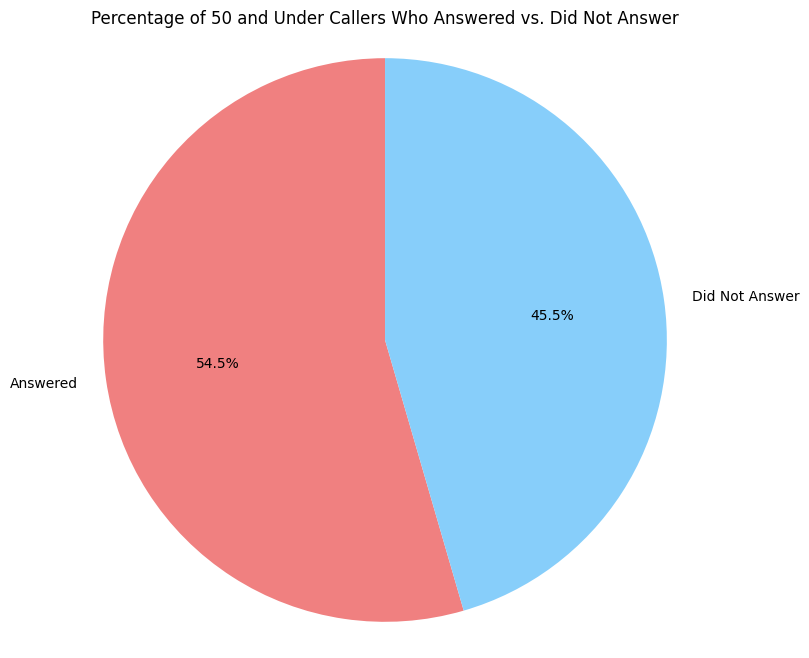

In [8]:
# Chart 3 🔧
import matplotlib.pyplot as plt

# Filter for callers 50 years old and under
under_50_callers = df[(df['age'] <= 50)]

# Calculate the percentage of 'answered' vs. 'not answered' within this group
answered_percentages_under_50 = under_50_callers['answered'].value_counts(normalize=True) * 100

# Map the 'answered' values to more descriptive labels for the pie chart
labels = answered_percentages_under_50.index.map({0: 'Did Not Answer', 1: 'Answered'})

# Create the pie chart
fig = plt.figure(figsize=(8, 8))
plt.pie(answered_percentages_under_50, labels=labels, autopct='%1.1f%%', startangle=90, colors=['lightcoral', 'lightskyblue'])
plt.title('Percentage of 50 and Under Callers Who Answered vs. Did Not Answer')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

/tmp/ipykernel_1439/2660812862.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='answered', y='income', data=df, palette='coolwarm')


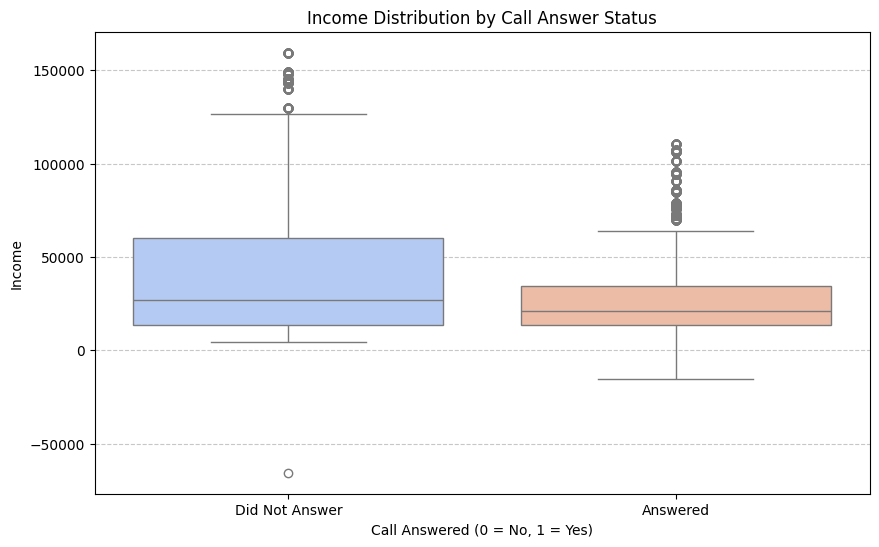

In [9]:
# Chart 4 🔧
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.boxplot(x='answered', y='income', data=df, palette='coolwarm')
plt.title('Income Distribution by Call Answer Status')
plt.xlabel('Call Answered (0 = No, 1 = Yes)')
plt.ylabel('Income')
plt.xticks(ticks=[0, 1], labels=['Did Not Answer', 'Answered'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

/tmp/ipykernel_1439/2399248254.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='job_category', y='answered_percentage', data=answered_by_job, palette='viridis')


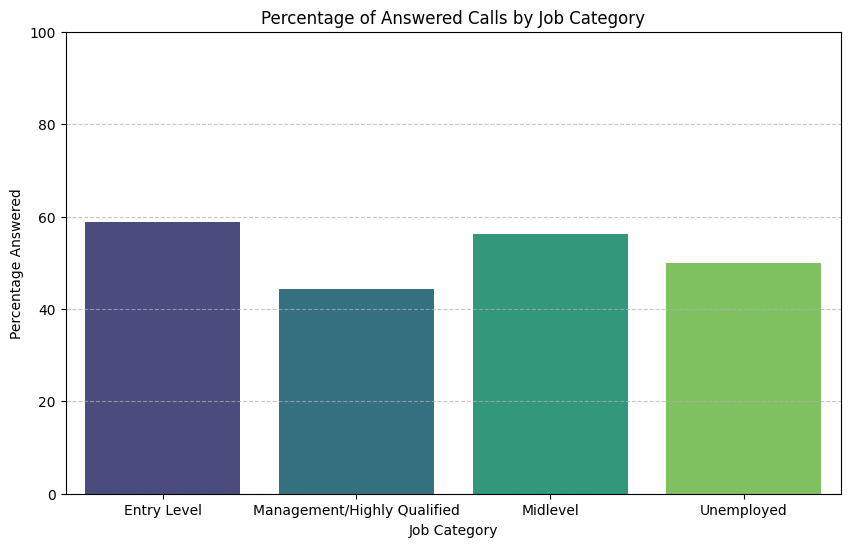

In [10]:
# Chart 5 🔧
import seaborn as sns
import matplotlib.pyplot as plt

# Map job categories to descriptive names
job_map = {
    0: 'Unemployed',
    1: 'Entry Level',
    2: 'Midlevel',
    3: 'Management/Highly Qualified'
}
df['job_category'] = df['job'].map(job_map)

# Calculate the proportion of answered calls for each job category
answered_by_job = df.groupby('job_category')['answered'].mean().reset_index()
answered_by_job['answered_percentage'] = answered_by_job['answered'] * 100

plt.figure(figsize=(10, 6))
sns.barplot(x='job_category', y='answered_percentage', data=answered_by_job, palette='viridis')
plt.title('Percentage of Answered Calls by Job Category')
plt.xlabel('Job Category')
plt.ylabel('Percentage Answered')
plt.ylim(0, 100) # Set y-axis limit from 0 to 100%
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Step 3: Summarize Your Findings
- Question 3.1: Which variables are NOT useful or applicable to the business need?  (you should reference the target variable and list any variables that are not correlated with the target)

- Question 3.2: Which variables are MOST useful or applicable to the business need, based on the output of your charts?   

- Question 3.3: List at least three ways that the dataset could be improved.  What data quality issues or data types should be fixed?



**Question 3.1: Which variables are NOT useful or applicable to the business need? (you should reference the target variable and list any variables that are not correlated with the target)**
I am realizing that customer_id is not very useful because even though it is a unique identifier, it does not do much for predictive analytics. I think that I found age may not be a very significant variable when trying to figure out if calls are answered or not, but I had to create those pie charts to see this. I was thinking that if customers were over the age of 50 versus under the age of 50 that would make a huge difference in who answered the calls. I found the contrary, in that age was not a good predictor of whether people answered calls or not. This is why I then went to look at income and job category to see if I found a larger discrepancy in these areas, which I did.

**Question 3.2: Which variables are MOST useful or applicable to the business need, based on the output of your charts?**
I found that income is very useful and applicable when trying to find who answers calls versus does not. I found that the box plot for income showed a large difference in distribution between those who answered and those who did not. The customers who had lower median incomes tended to answer more often than those who had higher incomes. This could be a variable we could look into further. Another variable that is useful is the job category variable. We see that 'Entrylevel' and 'Midlevel' job positions answer more frequently than 'Management/Highly Qualified' positions. This indicates that job category could be a predictor in answering the question of who answers the calls/who does not answer the calls.

**Question 3.3: List at least three ways that the dataset could be improved. What data quality issues or data types should be fixed?**
This dataset could be improved first and foremost by fixing any outstanding issues with the data, for example the variable of -65,600 for income, which is not possible. We need to address the same issue for the maximum age and figure out why that variable is so high or remove it entirely. We also need to fix the female column because it reads as object data (text), where it should be int64 because it is binary data, as a 0 or 1. This needs to be fixed, so that we could accurately use age as a predictor if we wanted. Overall, there are some missing data values or incorrect data values that need to be fixed before we can proceed with trying predictive analytics with the rest of the data variables.

## Submission Instructions

✅ **Before submitting:**
- Make sure all code cells are run and outputs are visible  
- All markdown questions are answered thoughtfully  
- Submit the assignment as an **HTML file** on Canvas

In [11]:
!jupyter nbconvert --to html "assignment_04_data_understanding.ipynb"

[NbConvertApp] Converting notebook assignment_04_data_understanding.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 5 image(s).
[NbConvertApp] Writing 539019 bytes to assignment_04_data_understanding.html
